<h1 style="text-align: center;">Visualizing and Analyzing Response Embeddings</h1>

In [10]:
import numpy as np
import pandas as pd
%matplotlib inline
import matplotlib.pyplot as plt
from ast import literal_eval
from sklearn.metrics import pairwise_distances
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D
import nltk
import umap.umap_ as umap
from sklearn.metrics import silhouette_score
from tqdm.auto import tqdm
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import plotly.express as px
import os


 

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')

# PARAMETERS 
RANDOM_STATE = 123 # for deterministic results
SAMPLE_SIZE = None # sample n response_ids for each scenario x type condition. 'None' for all
NEIGHBOURS = 150 # parameter selection for the single UMAP plot
EMBEDDING = 'original' # ['pca', 'umap', 'original'] whether to use UMAP, PCA-reduced or Original Embeddings for clustering

[nltk_data] Downloading package punkt to /Users/maass/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /Users/maass/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /Users/maass/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /Users/maass/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /Users/maass/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


## Loading embeddings & data preprocessing

In [11]:
# FULL DATASETS:
path_human = "./output/Human_responses_3_embedded.csv" # 321 unique response_ids
path_llm = "./output/LLM_responses_3_embedded.csv" # 358 unique response_ids

# always load:
path_action = "./output/actual_actions_embedded.csv"


df_human = pd.read_csv(path_human)
df_llm = pd.read_csv(path_llm)
df_action = pd.read_csv(path_action)

# # print the unique counts of response_ids per dataset
print("Human response_ids:", df_human['response_id'].nunique())
print("LLM response_ids:", df_llm['response_id'].nunique())

Human response_ids: 321
LLM response_ids: 358


In [12]:
df_human.head()

,response_id,scenario,response_number,response,embedding
0,1,1,1,Ask for help.,"[-0.01635012775659561, -0.0008211072417907417,..."
1,1,1,2,Take out a loan.,"[-0.036549996584653854, -6.420052523026243e-05..."
2,1,1,3,Sell some items.,"[-0.04528152570128441, -0.04024307057261467, -..."
3,1,1,4,Not get it.,"[-0.03167213127017021, 0.006149271037429571, -..."
4,1,1,5,Steal money.,"[0.00608329800888896, -0.0384681411087513, 0.0..."


In [13]:
# Add type column to each dataset
df_human['type'] = 'human'
df_llm['type'] = 'llm'
df_action['type'] = 'action'
df_action = df_action.rename(columns={'action': 'response'})



# Concatenate the datasets
df = pd.concat([df_human, df_llm], ignore_index=True)
# add 9 rows for the actual actions
df = pd.concat([df, df_action], ignore_index=True)

df[['scenario', 'type']].value_counts().sort_index()

# replace unqiue response_id with a sequential number for data protection
df['response_id'] = (pd.factorize(df['response_id'])[0] + 1).astype(str)


# print the unique counts of response_ids per dataset after concatenation
print(df[['scenario', 'type']].value_counts().sort_index())

scenario  type  
1         action      1
          human     500
          llm       605
2         action      1
          human     545
          llm       565
3         action      1
          human     530
          llm       580
4         action      1
          human     490
          llm       575
5         action      1
          human     525
          llm       595
6         action      1
          human     520
          llm       595
7         action      1
          human     515
          llm       550
8         action      1
          human     535
          llm       590
9         action      1
          human     515
          llm       585
Name: count, dtype: int64


In [14]:
# Sample X unique response_ids for each scenario and type
sampled_dfs = []
for (scenario, typ), group in df.groupby(['scenario', 'type']):
    # Skip sampling for action type - keep all actions
    if typ == 'action':
        sampled_dfs.append(group)
        continue
    
    # If SAMPLE_SIZE is None, do not sample
    if SAMPLE_SIZE is None:
        sampled_dfs.append(group)
        continue
    
    unique_ids = group['response_id'].unique()
    if len(unique_ids) >= SAMPLE_SIZE:
        sampled_ids = np.random.RandomState(RANDOM_STATE).choice(unique_ids, size=SAMPLE_SIZE, replace=False)
    else:
        sampled_ids = unique_ids
    sampled_dfs.append(group[group['response_id'].isin(sampled_ids)])

df = pd.concat(sampled_dfs, ignore_index=True)

df = df.reset_index(drop=True)

# df['type'] = pd.Categorical(df['type'], categories=['human', 'llm', 'action'], ordered=True)

df[['scenario', 'type']].value_counts().sort_index()

scenario  type  
1         action      1
          human     500
          llm       605
2         action      1
          human     545
          llm       565
3         action      1
          human     530
          llm       580
4         action      1
          human     490
          llm       575
5         action      1
          human     525
          llm       595
6         action      1
          human     520
          llm       595
7         action      1
          human     515
          llm       550
8         action      1
          human     535
          llm       590
9         action      1
          human     515
          llm       585
Name: count, dtype: int64

# Compute cosine distances
- to participant x scenario x type centroid
- mean pairwise cosine distance within type x scenario x participant

In [15]:
# remove NA values
df = df.dropna(subset=['embedding'])

# l2 normalize embeddings
df['embedding'] = df['embedding'].apply(lambda x: np.array(literal_eval(x))) # convert string to numpy array
df['embedding'] = df['embedding'].apply(lambda x: x / np.linalg.norm(x) if np.linalg.norm(x) != 0 else x)

# add distance centroid
def add_distances_to_centroid(df, category_cols, out_col='c_dist_cosine'):
    if isinstance(category_cols, str):
        category_cols = [category_cols]

    df = df.copy()

    valid = df[category_cols].notna().all(axis=1)
    df[out_col] = np.nan

    centroids = (
        df.loc[valid]
          .groupby(category_cols)['embedding']
          .apply(lambda x: np.vstack(x).mean(axis=0))
          .to_dict()
    )

    def key(row):
        return tuple(row[c] for c in category_cols) if len(category_cols) > 1 else row[category_cols[0]]

    df.loc[valid, out_col] = df.loc[valid].apply(
        lambda row: pairwise_distances(
            [row['embedding']],
            [centroids[key(row)]],
            metric='cosine'
        )[0, 0],
        axis=1
    )

    return df


def add_mean_pairwise_distance(df, category_cols=("scenario", "type", "response_id"),
                               embedding_col="embedding",
                               out_col="m_dist_cosine"):
    """
    Compute row-wise mean pairwise cosine distance within each group.

    For each row i in a group of size N, compute:
        MPD_i = (1/(N-1)) * sum_{j != i} d(x_i, x_j)
    where d is cosine distance.

    Adds column `out_col` to df.
    """
    df = df.copy()
    df[out_col] = np.nan

    # groupby over original indices so we can assign back without reordering
    for _, group in df.groupby(list(category_cols)):
        idx = group.index.to_numpy()
        N = len(idx)

        if N <= 1:
            continue

        # Stack embeddings into (N, d)
        X = np.vstack(df.loc[idx, embedding_col].to_numpy())

        # Pairwise cosine distance matrix (N x N), diagonal is 0
        D = pairwise_distances(X, metric="cosine")

        # Row-wise mean excluding diagonal: sum(row) / (N-1)
        mpd = D.sum(axis=1) / (N - 1)

        df.loc[idx, out_col] = mpd

    return df


df = add_distances_to_centroid(df, ['scenario', 'type', 'response_id'], out_col='p_dist_cosine')
df = add_mean_pairwise_distance(df, category_cols=['scenario', 'type', 'response_id'], out_col='m_dist_cosine')

In [16]:
matrix = np.vstack(df.embedding.values)

matrix = np.asarray(matrix)
matrix.shape 

(9922, 3072)

# ALGORITHMIC GROUPING

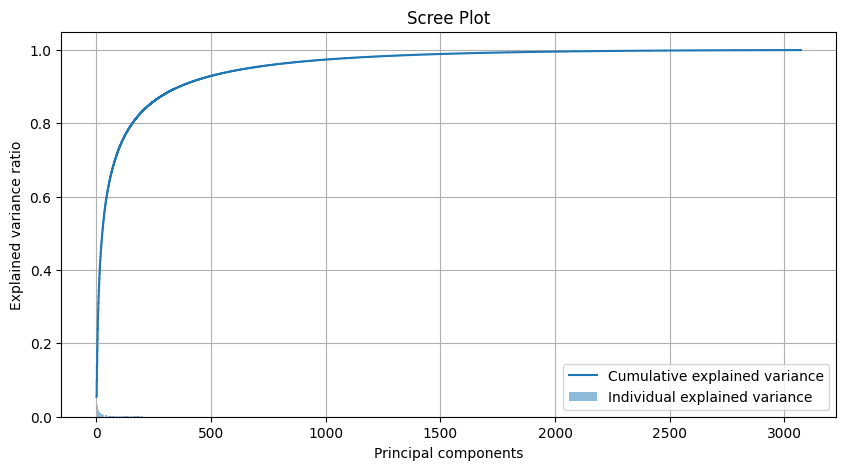

Number of components to retain 90.0% variance: 362
Original matrix shape: (9922, 3072)
PCA matrix shape: (9922, 362)


In [17]:
pca = PCA().fit(matrix)

explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)
n_components = len(explained_variance)


plt.figure(figsize=(10, 5))
plt.bar(range(1, n_components + 1), explained_variance, alpha=0.5, align='center', label='Individual explained variance')
plt.step(range(1, n_components + 1), cumulative_variance, where='mid', label='Cumulative explained variance')
plt.ylabel('Explained variance ratio')
plt.xlabel('Principal components')
plt.legend(loc='best')
plt.title('Scree Plot')
plt.grid()
plt.show()

desired_variance = 0.9
num_components = np.argmax(cumulative_variance >= desired_variance) + 1

print(f"Number of components to retain {desired_variance*100}% variance: {num_components}")

pca = PCA(n_components=num_components)
pca_matrix = pca.fit_transform(matrix)

print(f"Original matrix shape: {matrix.shape}")
print(f"PCA matrix shape: {pca_matrix.shape}")

In [18]:
# --- UMAP Transformation ---
umap_model = umap.UMAP(
    n_components=2,
    n_neighbors=NEIGHBOURS,
    min_dist=0.5,
    metric='cosine',
    init='random',
    random_state=RANDOM_STATE
)
umap_matrix = umap_model.fit_transform(matrix)

/Users/maass/Library/CloudStorage/OneDrive-Personal/Desktop/MPI/TASKS/possibility-generation/LLM_options/.venv/lib/python3.11/site-packages/umap/umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


In [19]:
# Embedding for clustering and use cosine distance instead of Euclidean for PCA and original Embedding
if EMBEDDING == 'pca':
    M = pca_matrix
elif EMBEDDING == 'umap':
    M = umap_matrix
else:
    M = matrix

if EMBEDDING == 'umap':
    METRIC = 'euclidean'
else:
    METRIC = 'cosine'


# Clustering uses M
print(M.shape, METRIC)

(9922, 3072) cosine


In [20]:
# ============================================================================
# K-MEANS GRID SEARCH ON EMBEDDINGS WITH MULTIPLE METRICS (BY SCENARIO AND TYPE)
# ============================================================================

print("=" * 80)
print("K-MEANS GRID SEARCH (BY SCENARIO AND TYPE)")
print("=" * 80)

# Initialize results storage
kmeans_results = []

# Convert matrix to float64
X_all = np.asarray(M, dtype=np.float64)
scenarios = sorted(df["scenario"].unique())
types = sorted(df["type"].unique())

# Grid search parameters
k_values = range(5, 26) 

# Perform grid search for each scenario and type
for scenario in tqdm(scenarios, desc="Processing scenarios"):
    for typ in types:
        # Get data for this scenario and type
        mask = (df["scenario"] == scenario) & (df["type"] == typ)
        X_scenario_type = X_all[mask.to_numpy()]
        
        # Skip if not enough samples
        if len(X_scenario_type) < 5:
            continue
        
        # Try each k value
        for k in k_values:
            # Skip if k >= number of samples
            if k >= len(X_scenario_type):
                continue
            
            # Fit K-Means
            kmeans = KMeans(
                n_clusters=k,
                random_state=RANDOM_STATE,
                n_init=10,
                max_iter=300
            )
            labels = kmeans.fit_predict(X_scenario_type)
            
            # Calculate WCSS (inertia)
            wcss = kmeans.inertia_
            
            # Calculate silhouette score
            sil_score = silhouette_score(X_scenario_type, labels, metric=METRIC)
            
            # Store results
            kmeans_results.append({
                'scenario': scenario,
                'type': typ,
                'k': k,
                'wcss': wcss,
                'silhouette_score': sil_score,
                'n_samples': len(X_scenario_type)
            })

# Convert to DataFrame
results_df = pd.DataFrame(kmeans_results)

# Display summary and store best k values
print("\n" + "=" * 80)
print("Best k per scenario and type (selected by Silhouette):")
print("-" * 40)

best_per_scenario_type = (
    results_df.loc[results_df.groupby(['scenario', 'type'])['silhouette_score'].idxmax()]
    [['scenario', 'type', 'k', 'wcss', 'silhouette_score']]
    .sort_values(['scenario', 'type'])
)
print(best_per_scenario_type.to_string(index=False))

# Store best k values in a dictionary
best_ks_kmeans = best_per_scenario_type.set_index(['scenario', 'type'])['k'].to_dict()

# Group by 'type' and calculate summary statistics
type_summary = best_per_scenario_type.groupby('type').agg(
    mean_k=('k', 'mean'),
    median_k=('k', 'median'),
    mean_wcss=('wcss', 'mean'),
    mean_silhouette=('silhouette_score', 'mean')
).reset_index()

# Build the exact print output as a string
content = (
    "\n" + "=" * 80 + "\n"
    "Summary Statistics by Type:\n"
    + "-" * 40 + "\n"
    + f"Best k values per scenario and type: {best_ks_kmeans}\n"
    + type_summary.to_string(index=False) + "\n"
    + "=" * 80
)

# Ensure output directory exists: ./output/{EMBEDDING}/
out_dir = f"./output/{EMBEDDING}"
try:
    os.makedirs(out_dir, exist_ok=True)  # if os is already available in your notebook/script
except NameError:
    # Fallback: if you truly can't import and os isn't defined, the directory must already exist.
    pass

out_path = f"{out_dir}/k_means_summary.txt"

# Write to file
f = open(out_path, "w", encoding="utf-8")
try:
    f.write(content)
finally:
    f.close()

print(content)

K-MEANS GRID SEARCH (BY SCENARIO AND TYPE)


Processing scenarios: 100%|██████████| 9/9 [10:06<00:00, 67.40s/it]


Best k per scenario and type (selected by Silhouette):
----------------------------------------
 scenario  type  k       wcss  silhouette_score
        1 human 13 226.034590          0.229053
        1   llm  5 203.403570          0.295968
        2 human 24 198.357855          0.218522
        2   llm  7 154.279959          0.417592
        3 human 12 247.046389          0.169626
        3   llm 12 172.578425          0.214470
        4 human 23 190.354584          0.224252
        4   llm  6 190.416606          0.281186
        5 human 24 206.063518          0.190108
        5   llm 16 174.686039          0.262659
        6 human 22 175.420901          0.315449
        6   llm  8 169.044315          0.366815
        7 human 22 237.957144          0.155533
        7   llm 10 167.153011          0.226852
        8 human  6 281.328087          0.239018
        8   llm  5 199.399231          0.283958
        9 human  6 264.795964          0.200059
        9   llm 10 181.060719          

In [21]:
# ============================================================================
# APPLY K-MEANS WITH BEST K VALUES PER SCENARIO AND TYPE
# ============================================================================

print("=" * 80)
print("APPLYING K-MEANS WITH BEST K VALUES PER SCENARIO AND TYPE")
print("=" * 80)

# Initialize cluster labels column
df['cluster_kmeans'] = -1

# Convert matrix to float64
X_all = np.asarray(M, dtype=np.float64)
scenarios = sorted(df["scenario"].unique())
types = sorted(df["type"].unique())

# Get best k mapping from previous results
best_k_mapping = best_per_scenario_type.set_index(['scenario', 'type'])['k'].to_dict()

# Apply K-Means for each scenario and type with its best k
for scenario in tqdm(scenarios, desc="Processing scenarios"):
    for typ in types:
        # Get data for this scenario and type
        mask = (df["scenario"] == scenario) & (df["type"] == typ)
        scenario_type_indices = df[mask].index
        X_scenario_type = X_all[mask.to_numpy()]
        
        # Skip if not enough samples
        if len(X_scenario_type) < 5:
            continue
        
        # Get best k for this scenario and type
        k = best_k_mapping.get((scenario, typ))
        if k is None or k >= len(X_scenario_type):
            print(f"Skipping {scenario}-{typ}: invalid k={k} for n_samples={len(X_scenario_type)}")
            continue
        
        # Fit K-Means with best k
        kmeans = KMeans(
            n_clusters=k,
            random_state=RANDOM_STATE,
            n_init=10,
            max_iter=300
        )
        labels = kmeans.fit_predict(X_scenario_type)
        
        # Store labels in dataframe
        df.loc[scenario_type_indices, 'cluster_kmeans'] = labels

APPLYING K-MEANS WITH BEST K VALUES PER SCENARIO AND TYPE


Processing scenarios: 100%|██████████| 9/9 [00:23<00:00,  2.65s/it]


## Labeling clusters based on centroids

In [22]:
# ============================================================================
# COMPUTE CLUSTER CENTROIDS AND LABEL REPRESENTATIVE RESPONSES (BY TYPE AND SCENARIO)
# ============================================================================

def add_cluster_centroid_distances_and_labels(df, cluster_col):
    """
    For each type x scenario x cluster combination:
    1. Compute the cluster centroid in RAW EMBEDDING space
    2. Calculate each point's distance to its cluster centroid
    3. Label the response closest to each centroid as representative
    
    Parameters:
    -----------
    df : DataFrame
        Main dataframe with cluster labels and 'embedding' column
    cluster_col : str
        Name of cluster column (e.g., 'cluster_kmeans')
    
    Returns:
    --------
    df : DataFrame with added columns:
        - {cluster_col}_centroid_dist : distance to cluster centroid
        - {cluster_col}_label : response text of the representative (closest to centroid)
    """
    df = df.copy()
    
    # Initialize new columns
    df[f'{cluster_col}_centroid_dist'] = np.nan
    df[f'{cluster_col}_label'] = ''
    
    scenarios = sorted(df['scenario'].unique())
    types = sorted(df['type'].unique())
    
    for scenario in scenarios:
        for typ in types:
            # Get data for this type and scenario
            mask = (df['scenario'] == scenario) & (df['type'] == typ)
            scenario_type_df = df[mask]
            
            # Get cluster labels for this type and scenario
            cluster_labels = scenario_type_df[cluster_col].values
            
            # Skip if no valid clusters (all -1 or NaN)
            unique_clusters = np.unique(cluster_labels[~np.isnan(cluster_labels)])
            if len(unique_clusters) == 0:
                continue
            
            # Process each cluster
            for cluster in unique_clusters:
                if cluster == -1:  # Skip noise points in DBSCAN
                    continue
                
                # Get rows in this cluster
                cluster_mask = scenario_type_df[cluster_col] == cluster
                cluster_df = scenario_type_df[cluster_mask]
                
                if len(cluster_df) == 0:
                    continue
                
                # Get embeddings for this cluster (raw embeddings)
                cluster_embeddings = np.vstack(cluster_df['embedding'].values)
                
                # Compute centroid in raw embedding space
                centroid = cluster_embeddings.mean(axis=0)
                
                # Compute distances to centroid
                distances = pairwise_distances(
                    cluster_embeddings, 
                    [centroid], 
                    metric=METRIC
                ).flatten()
                
                # Store distances in dataframe
                df.loc[cluster_df.index, f'{cluster_col}_centroid_dist'] = distances
                
                # Find representative (closest to centroid)
                representative_idx_in_cluster = np.argmin(distances)
                representative_global_idx = cluster_df.index[representative_idx_in_cluster]
                representative_response = df.loc[representative_global_idx, 'response']
                
                # Label all points in this cluster with the representative response
                df.loc[cluster_df.index, f'{cluster_col}_label'] = representative_response
    
    return df


# Apply to all clustering algorithms
print("=" * 80)
print("Computing cluster centroids and labeling with representative responses (by type and scenario)...")
print("=" * 80)

# K-Means
df = add_cluster_centroid_distances_and_labels(df, 'cluster_kmeans')
print("✓ K-Means centroids computed and labeled")

Computing cluster centroids and labeling with representative responses (by type and scenario)...
✓ K-Means centroids computed and labeled


In [23]:
# write final df to csv
df.to_csv(f"./output/{EMBEDDING}/distances_and_clusters.csv", index=False)

df

,response_id,scenario,response_number,response,embedding,type,p_dist_cosine,m_dist_cosine,cluster_kmeans,cluster_kmeans_centroid_dist,cluster_kmeans_label
0,0,1,NaN,Heinz decides to search for the medication on ...,"[0.005260357266790672, 0.020079167938468676, -...",action,4.440892e-16,NaN,-1,NaN,
1,1,1,1.0,Ask for help.,"[-0.016350127669122236, -0.0008211072373978083...",human,3.490124e-01,0.701954,8,0.252985,Ask family and friends for help.
2,1,1,2.0,Take out a loan.,"[-0.03654999512678898, -6.420052266950456e-05,...",human,2.593391e-01,0.626461,1,0.150067,Borrow money.
3,1,1,3.0,Sell some items.,"[-0.0452815249557506, -0.04024306991003608, -0...",human,3.330881e-01,0.688548,4,0.120272,Sell some things.
4,1,1,4.0,Not get it.,"[-0.03167213165280597, 0.006149271111719835, -...",human,4.220925e-01,0.763478,6,0.436060,Do nothing.
...,...,...,...,...,...,...,...,...,...,...,...
9919,121,9,1.0,Write a professional message to his boss expla...,"[0.0014117869685232446, -0.009827144215028826,...",llm,2.575674e-01,0.558893,7,0.309705,"Contact the boss again, leaving a voicemail if..."
9920,121,9,2.0,Call a trusted coworker who might be able to s...,"[0.003369820436634879, -0.026726785250840785, ...",llm,2.669967e-01,0.567670,1,0.094067,Call a coworker who might be able to cover his...
9921,121,9,3.0,Notify any regular customers at the store abou...,"[-0.020506576283039583, 0.0032769980369325457,...",llm,2.794703e-01,0.579282,5,0.165304,Inform any regular customers who visit early i...
9922,121,9,4.0,"Secure the shop, if possible, and notify the s...","[0.010518363110943289, -0.004931383006177282, ...",llm,3.147443e-01,0.612117,6,0.226059,Contact the local police to inform them about ...


# Dimensionality reduction using UMAP

### UMAP on raw Embeddings

/Users/maass/Library/CloudStorage/OneDrive-Personal/Desktop/MPI/TASKS/possibility-generation/LLM_options/.venv/lib/python3.11/site-packages/umap/umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")
/Users/maass/Library/CloudStorage/OneDrive-Personal/Desktop/MPI/TASKS/possibility-generation/LLM_options/.venv/lib/python3.11/site-packages/umap/umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")
/Users/maass/Library/CloudStorage/OneDrive-Personal/Desktop/MPI/TASKS/possibility-generation/LLM_options/.venv/lib/python3.11/site-packages/umap/umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(

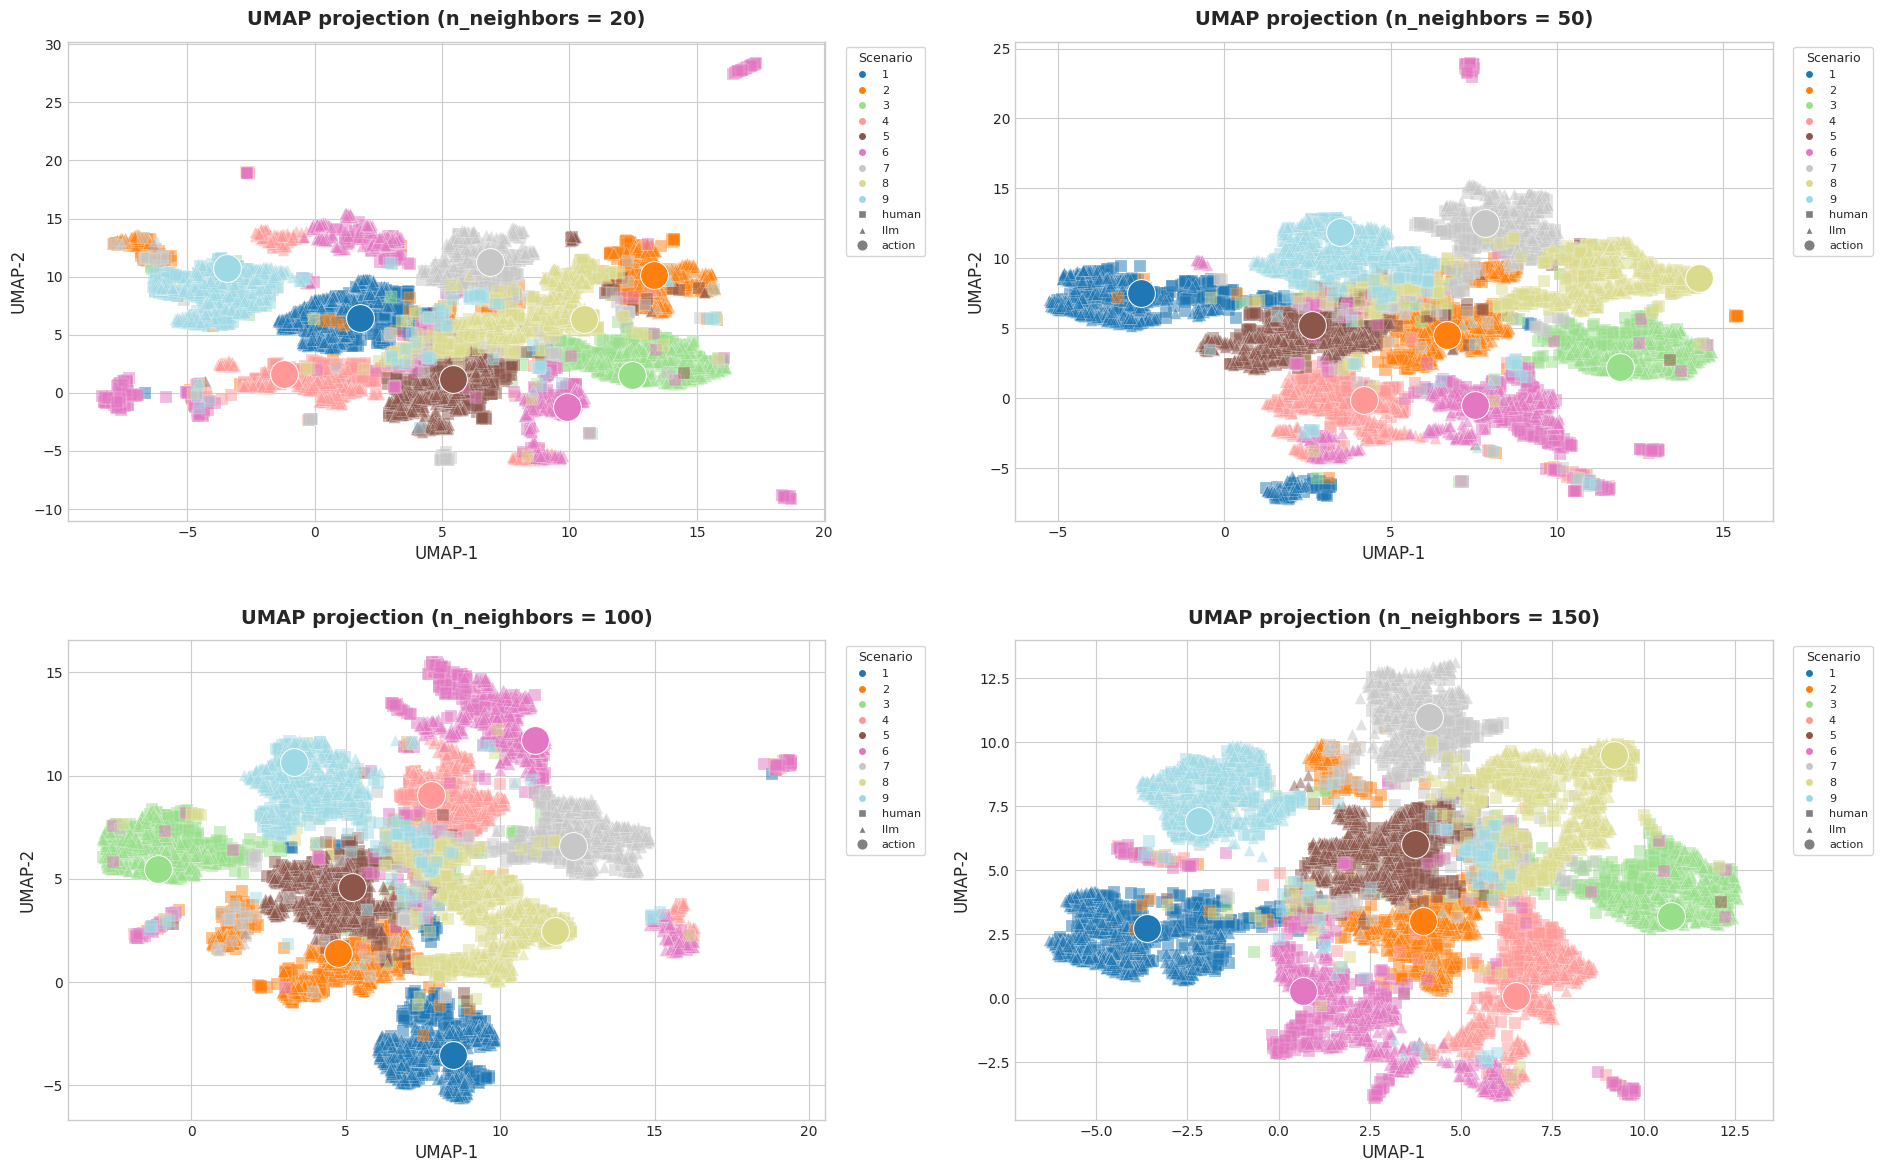

In [24]:
def plot_umap_with_neighbors(
    X, df, color_col, shape_col, neighbors_list, output_filename, random_state=RANDOM_STATE
):
    # --- Style and Setup ---
    plt.style.use('seaborn-v0_8-whitegrid')
    plt.rcParams.update({
        'font.family': 'DejaVu Sans',
        'axes.labelsize': 12,
        'axes.titlesize': 14,
        'legend.fontsize': 8,
        'xtick.labelsize': 10,
        'ytick.labelsize': 10
    })

    fig = plt.figure(figsize=(22, 14))
    gs = gridspec.GridSpec(2, 2, figure=fig, wspace=0.25, hspace=0.25)

    # --- Color & Marker Setup ---
    scenarios = df[color_col].unique()
    colors_palette = plt.cm.tab20(np.linspace(0, 1, len(scenarios)))
    color_map = dict(zip(scenarios, colors_palette))

    types = df[shape_col].unique()
    marker_shapes = ['o', 's', '^', 'D', 'v', '<', '>', 'p', 'h', '*']
    marker_dict = {typ: marker_shapes[i % len(marker_shapes)] for i, typ in enumerate(types)}

    # --- Plot Each UMAP Projection ---
    for idx, n_neighbors in enumerate(neighbors_list):
        ax = fig.add_subplot(gs[idx])

        umap_model = umap.UMAP(
            n_components=2, n_neighbors=n_neighbors, min_dist=0.5, metric='cosine',
            init='random', random_state=RANDOM_STATE,
        )
        X_umap = umap_model.fit_transform(X)
        df_umap = pd.DataFrame(X_umap, columns=['x', 'y'], index=df.index)
        df_umap[color_col] = df[color_col]
        df_umap[shape_col] = df[shape_col]

        # --- Plot Points ---
        for scenario in scenarios:
            for typ in types:
                mask = (df_umap[color_col] == scenario) & (df_umap[shape_col] == typ)
                if not mask.any():
                    continue

                if typ == 'action':
                    ax.scatter(
                        df_umap.loc[mask, 'x'],
                        df_umap.loc[mask, 'y'],
                        s=400,
                        c=[color_map[scenario]],
                        marker='o',
                        edgecolor='w',
                        linewidth=0.7,
                        alpha=1.0,
                        zorder=5
                    )
                else:
                    ax.scatter(
                        df_umap.loc[mask, 'x'],
                        df_umap.loc[mask, 'y'],
                        c=[color_map[scenario]],
                        s=70,
                        marker=marker_dict[typ],
                        edgecolor='w',
                        linewidth=0.3,
                        alpha=0.5
                    )

        # --- Axes Formatting ---
        ax.set_title(f"UMAP projection (n_neighbors = {n_neighbors})", pad=12, fontweight='semibold')
        ax.set_xlabel('UMAP-1')
        ax.set_ylabel('UMAP-2')

        # --- Legend ---
        color_handles = [
            Line2D([0], [0], marker='o', color='w',
                   markerfacecolor=color_map[s], markeredgecolor='w',
                   label=s, markersize=6)
            for s in scenarios
        ]

        shape_handles = [
            Line2D([0], [0], marker=marker_dict[t], color='w',
                   markerfacecolor='gray', markeredgecolor='w',
                   label=t, markersize=6)
            for t in types if t != 'action'
        ]

        # Single, unified "action" handle
        action_handle = Line2D(
            [0], [0], marker='o', color='w',
            markerfacecolor='gray', markeredgecolor='w',
            label='action', markersize=8, markeredgewidth=0.7
        )

        all_handles = color_handles + shape_handles + [action_handle]

        ax.legend(
            handles=all_handles,
            loc='upper left',
            bbox_to_anchor=(1.02, 1),
            frameon=True,
            fontsize=8,
            title='Scenario',
            title_fontsize=9
        )

    plt.tight_layout()
    plt.savefig(output_filename, dpi=300, bbox_inches='tight')
    plt.show()

neighbors_list = [20, 50, 100, 150]

plot_umap_with_neighbors(matrix, df, 'scenario', 'type', neighbors_list, output_filename='plots/umap.png')

### Single Plot on raw Embeddings

/Users/maass/Library/CloudStorage/OneDrive-Personal/Desktop/MPI/TASKS/possibility-generation/LLM_options/.venv/lib/python3.11/site-packages/umap/umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


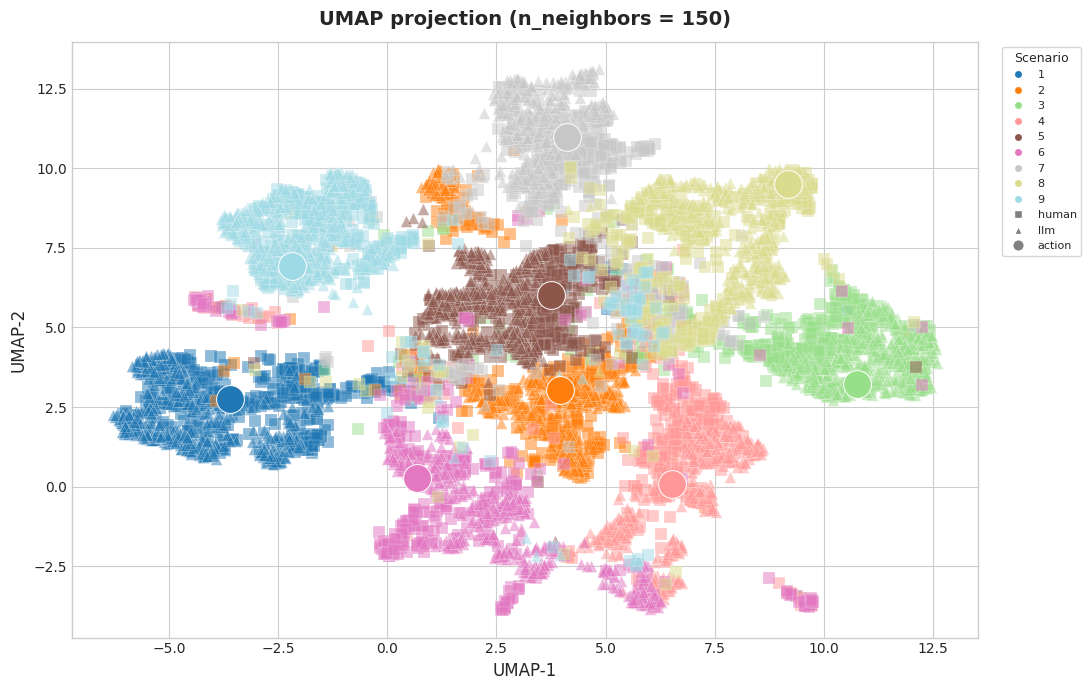

In [25]:
# --- Style and Setup ---
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'axes.labelsize': 12,
    'axes.titlesize': 14,
    'legend.fontsize': 8,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10
})

fig, ax = plt.subplots(figsize=(11, 7))

# --- Color & Marker Setup ---
color_col = 'scenario'
shape_col = 'type'

scenarios = df[color_col].unique()
colors_palette = plt.cm.tab20(np.linspace(0, 1, len(scenarios)))
color_map = dict(zip(scenarios, colors_palette))

types = df[shape_col].unique()
marker_shapes = ['o', 's', '^', 'D', 'v', '<', '>', 'p', 'h', '*']
marker_dict = {typ: marker_shapes[i % len(marker_shapes)] for i, typ in enumerate(types)}

# --- UMAP with 50 neighbors ---
umap_model = umap.UMAP(
    n_components=2,
    n_neighbors=NEIGHBOURS,
    min_dist=0.5,
    metric='cosine',
    init='random',
    random_state=RANDOM_STATE
)
X_umap = umap_model.fit_transform(matrix)

# --- Assemble plotting frame ---
df_umap = pd.DataFrame(X_umap, columns=['x', 'y'], index=df.index)
df_umap[color_col] = df[color_col]
df_umap[shape_col] = df[shape_col]

# --- Plot Points ---
for scenario in scenarios:
    for typ in types:
        mask = (df_umap[color_col] == scenario) & (df_umap[shape_col] == typ)
        if not mask.any():
            continue

        if typ == 'action':
            ax.scatter(
                df_umap.loc[mask, 'x'],
                df_umap.loc[mask, 'y'],
                s=400,
                c=[color_map[scenario]],
                marker='o',
                edgecolor='w',
                linewidth=0.7,
                alpha=1.0,
                zorder=5
            )
        else:
            ax.scatter(
                df_umap.loc[mask, 'x'],
                df_umap.loc[mask, 'y'],
                c=[color_map[scenario]],
                s=70,
                marker=marker_dict[typ],
                edgecolor='w',
                linewidth=0.3,
                alpha=0.5
            )

# --- Axes Formatting ---
ax.set_title(f"UMAP projection (n_neighbors = {NEIGHBOURS})", pad=12, fontweight='semibold')
ax.set_xlabel('UMAP-1')
ax.set_ylabel('UMAP-2')

# --- Legend ---
color_handles = [
    Line2D([0], [0], marker='o', color='w',
           markerfacecolor=color_map[s], markeredgecolor='w',
           label=s, markersize=6)
    for s in scenarios
]

shape_handles = [
    Line2D([0], [0], marker=marker_dict[t], color='w',
           markerfacecolor='gray', markeredgecolor='w',
           label=t, markersize=6)
    for t in types if t != 'action'
]

action_handle = Line2D(
    [0], [0], marker='o', color='w',
    markerfacecolor='gray', markeredgecolor='w',
    label='action', markersize=8, markeredgewidth=0.7
)

all_handles = color_handles + shape_handles + [action_handle]

ax.legend(
    handles=all_handles,
    loc='upper left',
    bbox_to_anchor=(1.02, 1),
    frameon=True,
    fontsize=8,
    title='Scenario',
    title_fontsize=9
)

plt.tight_layout()
plt.savefig('plots/umap_single.png', dpi=300, bbox_inches='tight')
plt.show()

/Users/maass/Library/CloudStorage/OneDrive-Personal/Desktop/MPI/TASKS/possibility-generation/LLM_options/.venv/lib/python3.11/site-packages/umap/umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")
/var/folders/gt/hw0223251jd3kq9z3k5_jxm00000gq/T/ipykernel_34053/3413230939.py:130: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


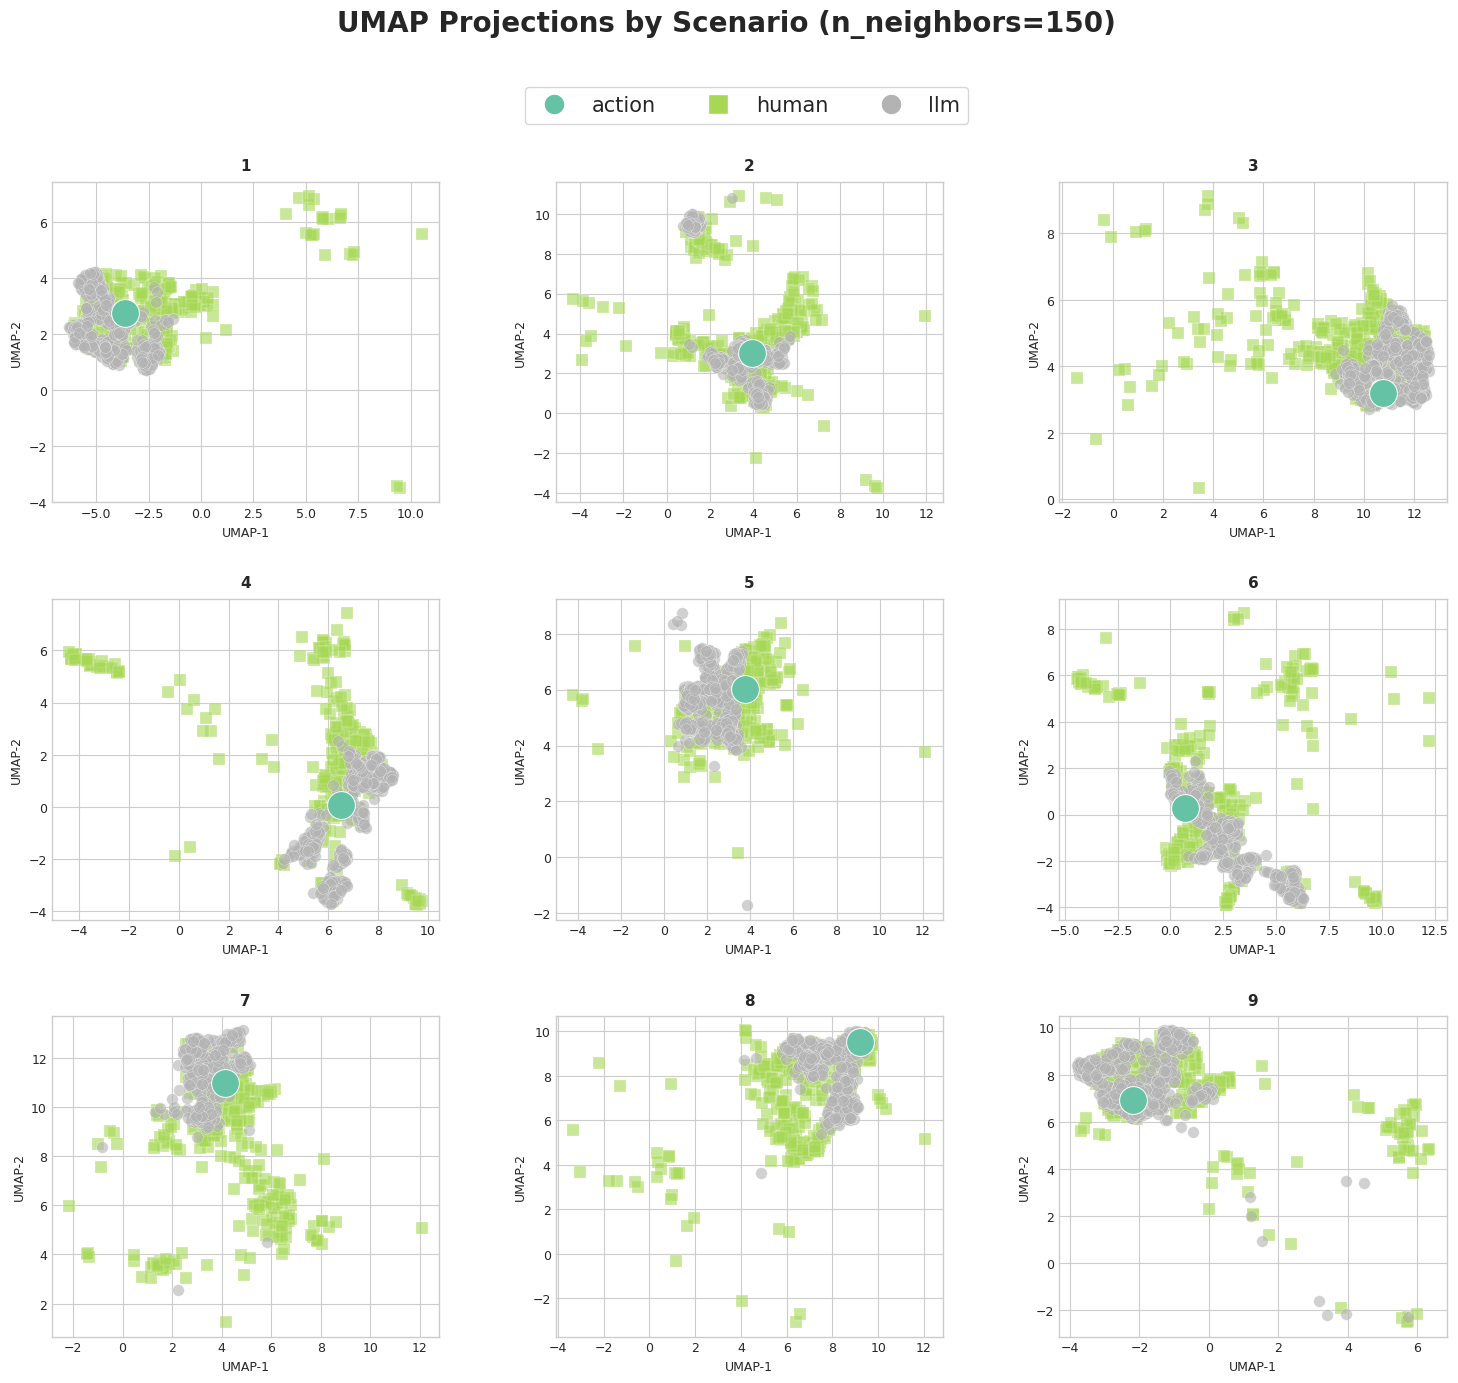

In [26]:
def plot_umap_by_scenario(
    X, df, color_col, shape_col, neighbors_list, output_filename, random_state=RANDOM_STATE
):
    """
    Create UMAP plots organized by scenario, with one subplot per scenario.
    """
    # --- Style and Setup ---
    plt.style.use('seaborn-v0_8-whitegrid')
    plt.rcParams.update({
        'font.family': 'DejaVu Sans',
        'axes.labelsize': 10,
        'axes.titlesize': 11,
        'legend.fontsize': 7,
        'xtick.labelsize': 9,
        'ytick.labelsize': 9
    })

    scenarios = sorted(df[color_col].unique())
    n_scenarios = len(scenarios)
    
    # Calculate grid dimensions (e.g., 3x3 for 9 scenarios)
    n_cols = int(np.ceil(np.sqrt(n_scenarios)))
    n_rows = int(np.ceil(n_scenarios / n_cols))
    
    fig = plt.figure(figsize=(n_cols * 6, n_rows * 5))
    gs = gridspec.GridSpec(n_rows, n_cols, figure=fig, wspace=0.3, hspace=0.3)

    # --- Type/Marker Setup ---
    types = df[shape_col].unique()
    marker_shapes = ['o', 's', 'o', 'D', 'v', '<', '>', 'p', 'h', '*']
    marker_dict = {typ: marker_shapes[i % len(marker_shapes)] for i, typ in enumerate(types)}
    
    # Colors for types
    type_colors = plt.cm.Set2(np.linspace(0, 1, len(types)))
    type_color_map = dict(zip(types, type_colors))

    # --- Compute UMAP once ---
    n_neighbors = neighbors_list[0] if neighbors_list else NEIGHBOURS
    umap_model = umap.UMAP(
        n_components=2, n_neighbors=n_neighbors, min_dist=0.5, metric='cosine',
        init='random', random_state=RANDOM_STATE
    )
    X_umap = umap_model.fit_transform(X)
    
    # Create UMAP dataframe
    df_umap = pd.DataFrame(X_umap, columns=['x', 'y'], index=df.index)
    df_umap[color_col] = df[color_col]
    df_umap[shape_col] = df[shape_col]

    # --- Plot Each Scenario ---
    for idx, scenario in enumerate(scenarios):
        row = idx // n_cols
        col = idx % n_cols
        ax = fig.add_subplot(gs[row, col])
        
        # Filter data for this scenario
        scenario_mask = df_umap[color_col] == scenario
        scenario_data = df_umap[scenario_mask]
        
        # Plot each type
        for typ in types:
            type_mask = scenario_data[shape_col] == typ
            if not type_mask.any():
                continue
            
            if typ == 'action':
                ax.scatter(
                    scenario_data.loc[type_mask, 'x'],
                    scenario_data.loc[type_mask, 'y'],
                    s=400,
                    c=[type_color_map[typ]],
                    marker='o',
                    edgecolor='w',
                    linewidth=0.7,
                    alpha=1.0,
                    zorder=5,
                    label=typ
                )
            else:
                ax.scatter(
                    scenario_data.loc[type_mask, 'x'],
                    scenario_data.loc[type_mask, 'y'],
                    c=[type_color_map[typ]],
                    s=70,
                    marker=marker_dict[typ],
                    edgecolor='w',
                    linewidth=0.3,
                    alpha=0.6,
                    label=typ
                )
        
        # Formatting
        ax.set_title(f"{scenario}", fontweight='semibold', pad=8)
        ax.set_xlabel('UMAP-1', fontsize=9)
        ax.set_ylabel('UMAP-2', fontsize=9)
        
        # Add custom legend with consistent marker sizes to first subplot
        if idx == 0:
            legend_handles = []
            for typ in types:
                handle = Line2D(
                    [0], [0], 
                    marker=marker_dict.get(typ, 'o'), 
                    color='w',
                    markerfacecolor=type_color_map[typ], 
                    markeredgecolor='w',
                    label=typ, 
                    markersize=15  # Consistent size for all types
                )
                legend_handles.append(handle)
            
            # Place legend in upper right corner of the figure, next to title
            fig.legend(
                handles=legend_handles,
                loc='upper right',
                bbox_to_anchor=(0.64, 0.95),
                fontsize=15, 
                frameon=True,
                ncol=len(types)  # Horizontal layout
            )

    # Remove empty subplots
    for idx in range(n_scenarios, n_rows * n_cols):
        row = idx // n_cols
        col = idx % n_cols
        fig.delaxes(fig.add_subplot(gs[row, col]))

    plt.suptitle(f'UMAP Projections by Scenario (n_neighbors={n_neighbors})', 
                 fontsize=20, fontweight='bold', y=0.995)
    plt.tight_layout()
    plt.savefig(output_filename, dpi=300, bbox_inches='tight')
    plt.show()

# Call the function
neighbors_list = [NEIGHBOURS]  # Use one n_neighbors value for clarity
plot_umap_by_scenario(matrix, df, 'scenario', 'type', neighbors_list, output_filename='plots/umap_by_scenario.png')

### Plot K-Means

/var/folders/gt/hw0223251jd3kq9z3k5_jxm00000gq/T/ipykernel_34053/2600886173.py:111: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


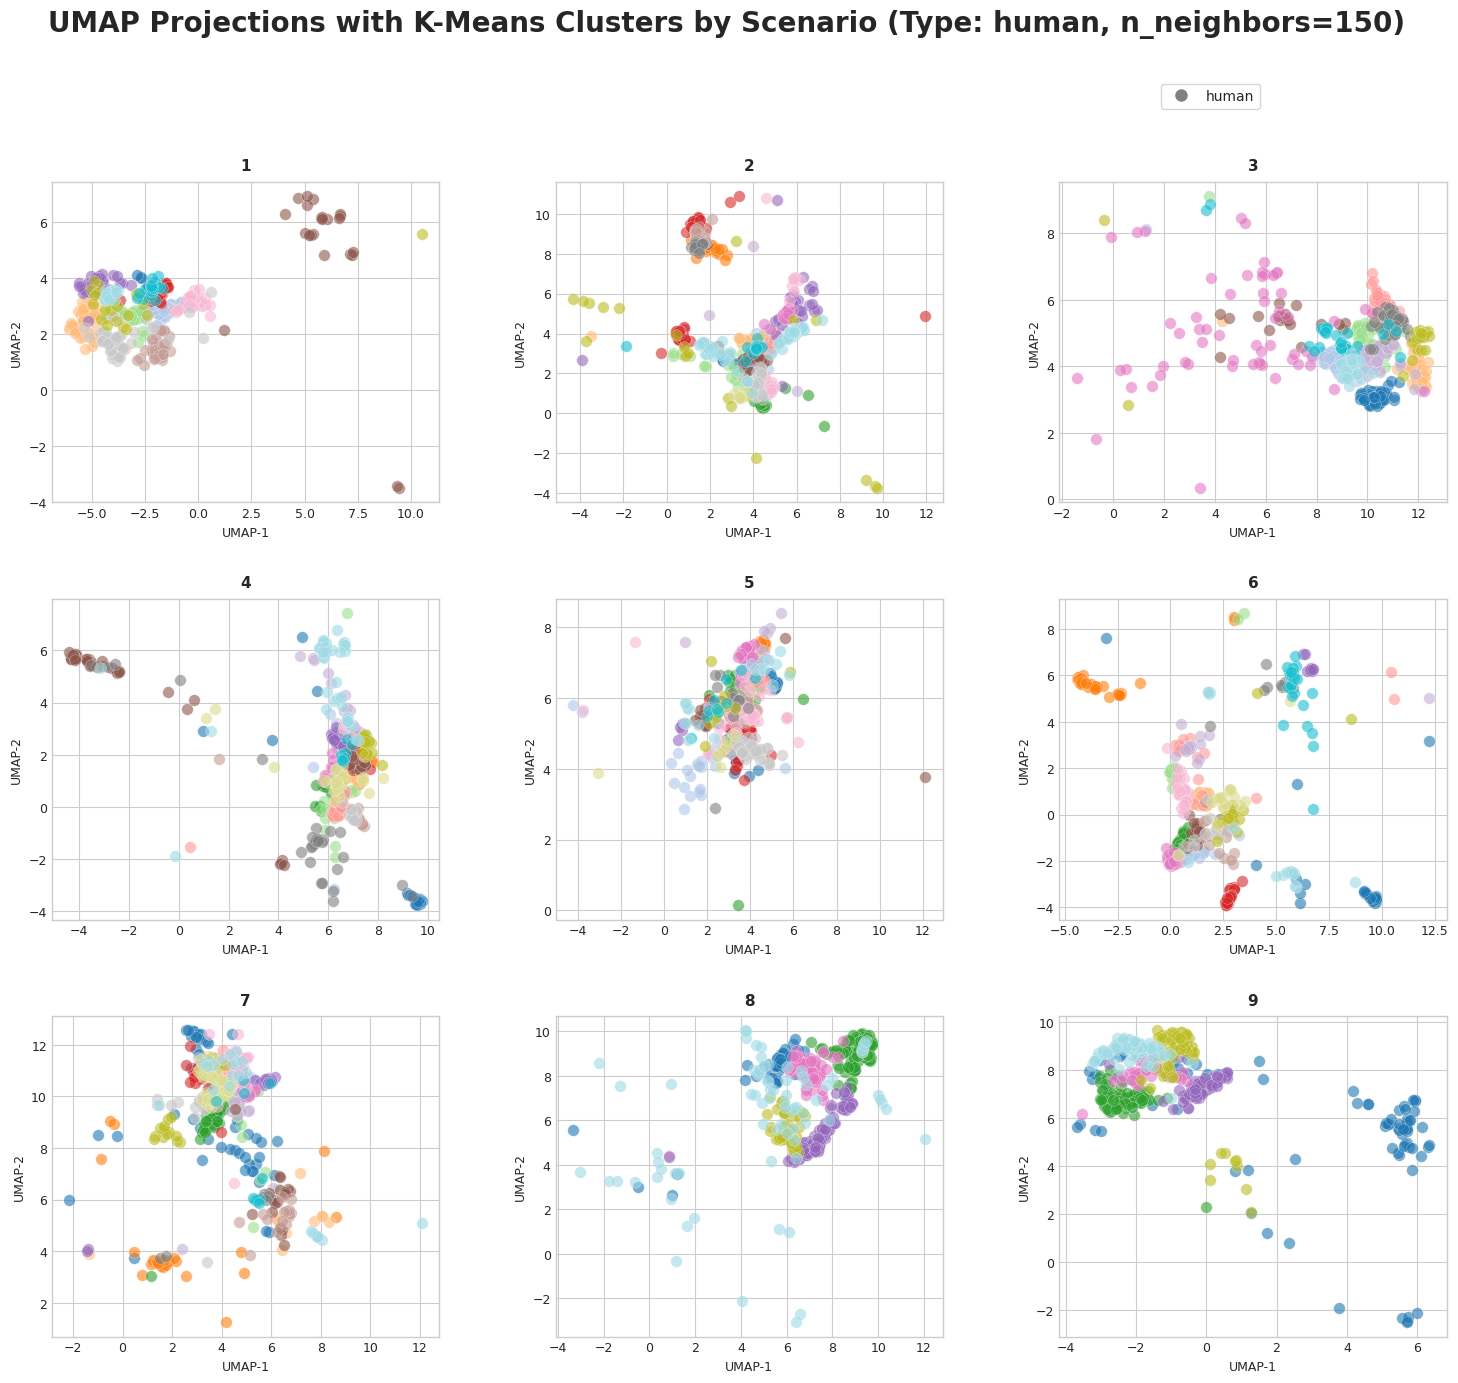

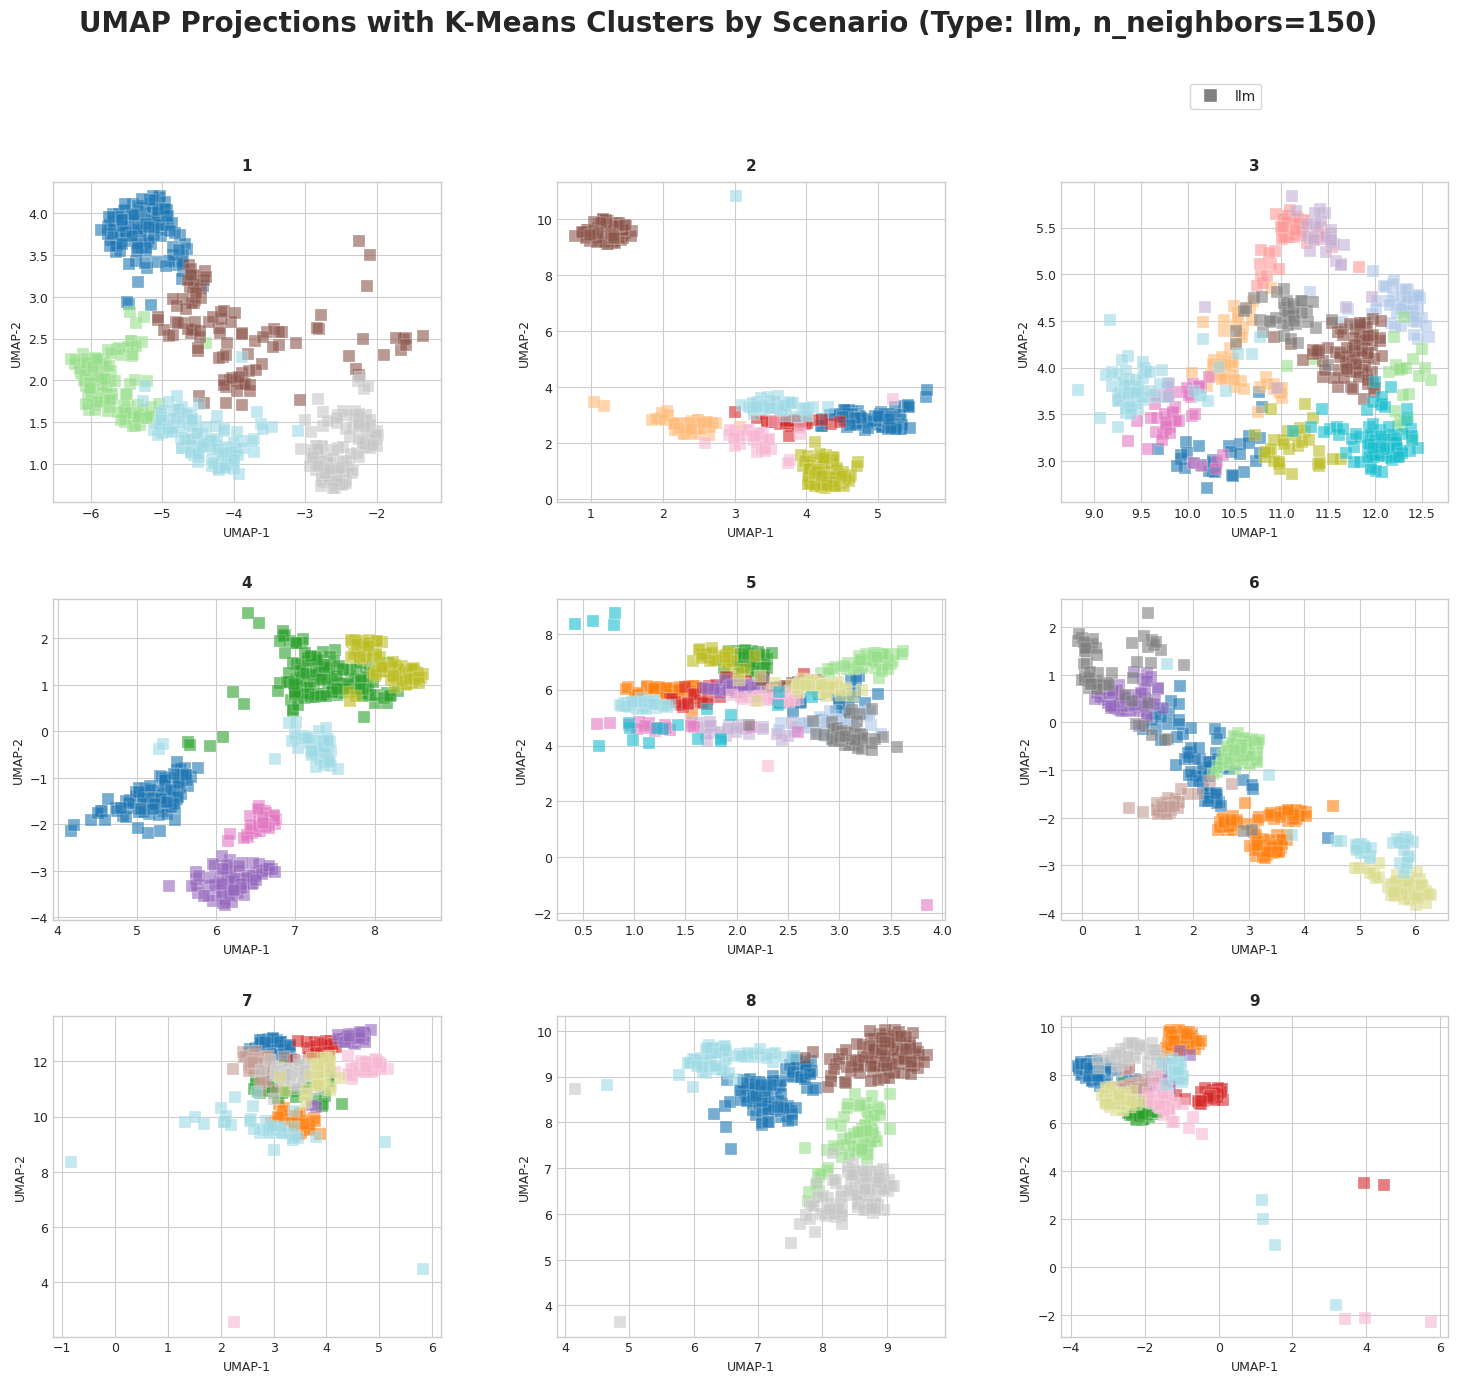

Saved interactive plot for type 'human' to plots/original/kmeans_human.html
Saved interactive plot for type 'llm' to plots/original/kmeans_llm.html


In [27]:
# --- Style and Setup ---
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'axes.labelsize': 10,
    'axes.titlesize': 11,
    'legend.fontsize': 7,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9
})

scenarios = sorted(df['scenario'].unique())
n_scenarios = len(scenarios)

# Calculate grid dimensions
n_cols = int(np.ceil(np.sqrt(n_scenarios)))
n_rows = int(np.ceil(n_scenarios / n_cols))

# --- Type/Marker Setup ---
types = [t for t in df['type'].unique() if t != 'action']  # Exclude 'action'
marker_shapes = ['o', 's', '^', 'D', 'v', '<', '>', 'p', 'h', '*']
marker_dict = {typ: marker_shapes[i % len(marker_shapes)] for i, typ in enumerate(types)}

# --- Create UMAP dataframe ---
df_umap = pd.DataFrame(X_umap, columns=['x', 'y'], index=df.index)
df_umap['scenario'] = df['scenario']
df_umap['type'] = df['type']
df_umap['cluster_kmeans'] = df['cluster_kmeans']
df_umap['cluster_label'] = df['cluster_kmeans_label']

# --- Plot for each type ---
for typ in types:
    fig = plt.figure(figsize=(n_cols * 6, n_rows * 5))
    gs = gridspec.GridSpec(n_rows, n_cols, figure=fig, wspace=0.3, hspace=0.3)

    for idx, scenario in enumerate(scenarios):
        row = idx // n_cols
        col = idx % n_cols
        ax = fig.add_subplot(gs[row, col])
        
        # Filter data for this scenario and type
        scenario_mask = (df_umap['scenario'] == scenario) & (df_umap['type'] == typ)
        scenario_data = df_umap[scenario_mask]
        
        # Get unique clusters for this scenario
        clusters = sorted(scenario_data['cluster_kmeans'].unique())
        
        # Generate colors for clusters
        if len(clusters) > 0:
            cluster_colors = plt.cm.tab20(np.linspace(0, 1, len(clusters)))
            cluster_color_map = dict(zip(clusters, cluster_colors))
        
        # Plot by cluster
        for cluster in clusters:
            cluster_mask = scenario_data['cluster_kmeans'] == cluster
            cluster_data = scenario_data[cluster_mask]
            
            if not cluster_mask.any():
                continue
            
            # Color and alpha
            color = cluster_color_map[cluster]
            alpha = 0.6
            
            ax.scatter(
                cluster_data['x'],
                cluster_data['y'],
                c=[color],
                s=70,
                marker=marker_dict[typ],
                edgecolor='w',
                linewidth=0.3,
                alpha=alpha
            )
        
        # Formatting
        ax.set_title(f"{scenario}", fontweight='semibold', pad=8)
        ax.set_xlabel('UMAP-1', fontsize=9)
        ax.set_ylabel('UMAP-2', fontsize=9)
    
    # Add legend to first subplot
    legend_handles = []
    handle = Line2D(
        [0], [0], 
        marker=marker_dict.get(typ, 'o'), 
        color='w',
        markerfacecolor='grey', 
        markeredgecolor='w',
        label=typ, 
        markersize=10
    )
    legend_handles.append(handle)
    
    fig.legend(
        handles=legend_handles,
        loc='upper right',
        bbox_to_anchor=(0.8, 0.95),
        fontsize=10,  
        frameon=True,
        ncol=len(legend_handles)
    )

    # Remove empty subplots
    for idx in range(n_scenarios, n_rows * n_cols):
        row = idx // n_cols
        col = idx % n_cols
        fig.delaxes(fig.add_subplot(gs[row, col]))

    plt.suptitle(f'UMAP Projections with K-Means Clusters by Scenario (Type: {typ}, n_neighbors={NEIGHBOURS})', 
                 fontsize=20, fontweight='bold', y=0.995)
    plt.tight_layout()
    plt.savefig(f'plots/{EMBEDDING}/kmeans_{typ}.png', dpi=300, bbox_inches='tight')
    plt.show()


# --- INTERACTIVE HTML PLOT FOR EACH TYPE ---
for typ in types:
    if typ == 'action':
        continue  # Skip 'action' type

    # Filter data for the current type
    df_interactive = df_umap[df_umap['type'] == typ].copy()

    # Add the response column from the original df, aligning indices
    df_interactive['response'] = df.loc[df_interactive.index, 'response']

    # Make sure scenario is a string (Plotly facet labels look nicer that way)
    df_interactive['scenario'] = df_interactive['scenario'].astype(str)

    # Optional: ensure clusters are treated as discrete categories
    df_interactive['cluster_label'] = df_interactive['cluster_label'].astype(str)

    df_interactive['cluster'] = df_interactive['cluster_kmeans'].astype(str)

    df_interactive['size'] = 1

    # --- Build Plotly scatter with facets + hover ---
    fig_int = px.scatter(
        df_interactive,
        x="x",
        y="y",
        color="cluster_label",
        symbol="type",
        size="size",
        facet_col="scenario",
        facet_col_wrap=n_cols,
        hover_data={
            "scenario": True,
            "type": True,
            "cluster_label": True,
            "x": ':.3f',
            "y": ':.3f',
            "response": True,  # Include response in hover
            "size": False  # Hide size from hover
        },
        labels={
            "x": "UMAP-1",
            "y": "UMAP-2",
            "cluster_label": "Cluster",
            "type": "Type",
            "scenario": "Scenario",
        },
        title=f"UMAP Projections with K-Means Clusters by Scenario (Type: {typ}, n_neighbors={NEIGHBOURS})"
    )

    # Make markers a bit cleaner
    fig_int.update_traces(
        marker=dict(
            line=dict(width=0.5, color="white")
        )
    )

    # Layout tuning: approximate size based on the grid
    fig_int.update_layout(
        legend_title_text="",
        showlegend=False,
        height=max(500, n_rows * 450),
        width=max(800, n_cols * 500),
        margin=dict(l=40, r=40, t=80, b=40)
    )

    # Save the plot as an HTML file
    output_path = f"plots/{EMBEDDING}/kmeans_{typ}.html"
    fig_int.write_html(output_path, include_plotlyjs="cdn", full_html=True)
    print(f"Saved interactive plot for type '{typ}' to {output_path}")


## Graphic for Scenario 3

/Users/maass/Library/CloudStorage/OneDrive-Personal/Desktop/MPI/TASKS/possibility-generation/LLM_options/.venv/lib/python3.11/site-packages/umap/umap_.py:1943: UserWarning:

n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.



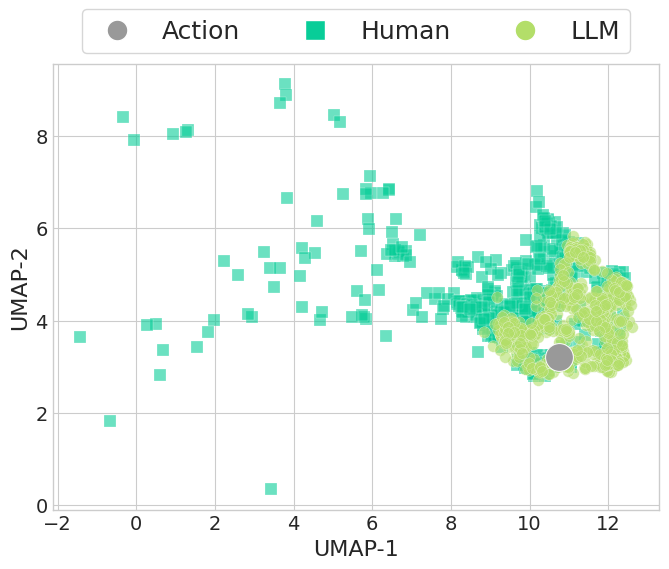

In [28]:
def plot_umap_single_scenario(
    X, df, scenario_value, color_col, shape_col,
    output_filename, random_state=RANDOM_STATE
):
    # --- Style and Setup ---
    plt.style.use('seaborn-v0_8-whitegrid')
    BASE_FONT = 16  # <- 
    plt.rcParams.update({
        'font.family': 'DejaVu Sans',
        'font.size': BASE_FONT,          # global default
        'axes.labelsize': BASE_FONT,
        'axes.titlesize': BASE_FONT,
        'legend.fontsize': BASE_FONT + 2,
        'xtick.labelsize': BASE_FONT - 2,
        'ytick.labelsize': BASE_FONT - 2,
    })


    label_map = {'action': 'Action', 'human': 'Human', 'llm': 'LLM'}

    # --- Marker / Color setup ---
    type_order = ['action', 'human', 'llm'] 
    types = [t for t in type_order if t in df[shape_col].unique()]

    type_color_map = {
        'action': '0.6',      # grey (string grayscale in matplotlib)
        'human':  '#08cd98',  
        'llm':    "#b3de69",
    }

    marker_dict = {
        'action': 'o',
        'human':  's',
        'llm':    'o',
    }

    # --- Compute UMAP once ---
    umap_model = umap.UMAP(
        n_components=2,
        n_neighbors=NEIGHBOURS,
        min_dist=0.5,
        metric='cosine',
        init='random',
        random_state=RANDOM_STATE
    )
    X_umap = umap_model.fit_transform(X)

    df_umap = pd.DataFrame(X_umap, columns=['x', 'y'], index=df.index)
    df_umap[color_col] = df[color_col]
    df_umap[shape_col] = df[shape_col]

    # --- Filter to one scenario ---
    scenario_data = df_umap[df_umap[color_col] == scenario_value]

    # --- Plot ---
    fig, ax = plt.subplots(figsize=(7, 6))

    for typ in types:
        mask = scenario_data[shape_col] == typ
        if not mask.any():
            continue

        if typ == 'action':
            ax.scatter(
                scenario_data.loc[mask, 'x'],
                scenario_data.loc[mask, 'y'],
                s=400,
                c=[type_color_map[typ]],
                marker='o',
                edgecolor='w',
                linewidth=0.7,
                alpha=1.0,
                zorder=5,
                label=label_map.get(typ, typ)  # UPDATED
            )
        else:
            ax.scatter(
                scenario_data.loc[mask, 'x'],
                scenario_data.loc[mask, 'y'],
                s=70,
                c=[type_color_map[typ]],
                marker=marker_dict[typ],
                edgecolor='w',
                linewidth=0.3,
                alpha=0.6,
                label=label_map.get(typ, typ)  # UPDATED
            )

    ax.set_xlabel("UMAP-1")
    ax.set_ylabel("UMAP-2")

    # --- Legend ---
    legend_handles = [
        Line2D(
            [0], [0],
            marker=marker_dict.get(typ, 'o'),
            color='w',
            markerfacecolor=type_color_map[typ],
            markeredgecolor='w',
            label=label_map.get(typ, typ),  # UPDATED
            markersize=15
        )
        for typ in types
    ]

    ax.legend(
        handles=legend_handles,
        loc="upper center",
        bbox_to_anchor=(0.5, 1.15),
        ncol=len(legend_handles),
        frameon=True,
    )

    plt.tight_layout()
    plt.savefig(output_filename, dpi=300, bbox_inches='tight')
    plt.show()


plot_umap_single_scenario(
    matrix,
    df,
    scenario_value=3,
    color_col='scenario',
    shape_col='type',
    output_filename='plots/umap_scenario_3.png'
)